In [1]:
import numpy as np
from matplotlib import pyplot as plt
import utils.lib.granada_phases as granada
import utils.lib.constants as constants
import utils.lib.nn_studio as nn_studio  # Modulo per la gestione delle matrici T e canali nucleari
import emcee
import corner

/home/aliverga/LaboModellizzazione/lmd_forza_nucleare/utils/lib/__init__.py:4: SyntaxWarning: "\c" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\c"? A raw string is also an option.
  Questo modulo contiene una libreria per il calcolo delle osservabili di scattering nucleone-nucleone (NN) e degli stati legati (deuterone) utilizzando la **Teoria di Campo Efficace Chirale ($\chi$EFT)**.


In [2]:
%matplotlib widget
plt.close('all')

In [3]:
# plot dei dati
dati3S1 = granada.delta_3S1
errori3S1 = granada.delta_3S1_errors

TLab = granada.Tlabs

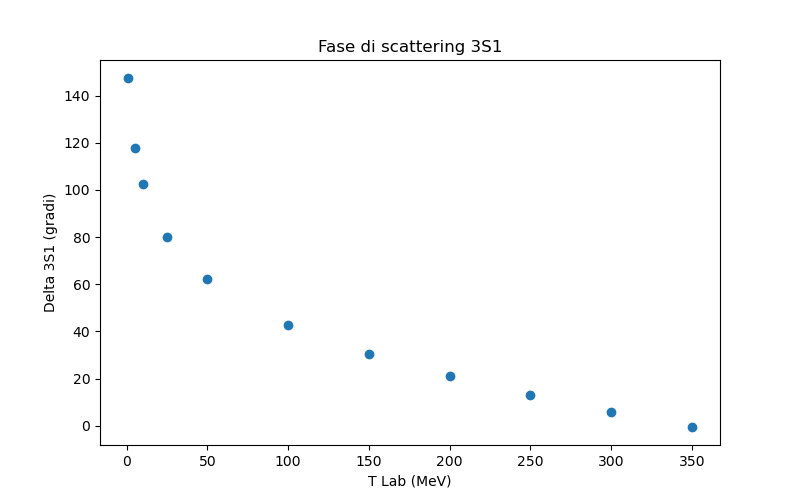

In [4]:
plt.figure(figsize=(8, 5))
plt.errorbar(TLab, dati3S1, yerr=errori3S1, fmt='o', label='Dati Granada')
plt.xlabel('T Lab (MeV)')
plt.ylabel('Delta 3S1 (gradi)')
plt.title('Fase di scattering 3S1')
plt.show()

In [5]:
import numpy as np
import utils.lib.nn_studio as nn_studio
import utils.lib.chiral_potential as chiral_potential
from scipy import linalg
import utils.lib.lec_values as lec_values

def calcola_energia_deuterone(jmin=0, jmax=1, tzmin=0, tzmax=0, Np=130, mesh_type='gauleg_finite',
                              ordine_potenziale='LO', Lambda=500.0, lecs=None):
    """
    Calcola l'autovalore di energia (stato fondamentale) del deuterone.
    Restituisce l'energia e la funzione d'onda corrispondente.
    """
    nn = nn_studio.nn_studio(jmin=jmin, jmax=jmax, tzmin=tzmin, tzmax=tzmax, Np=Np, mesh_type=mesh_type)
    potential = chiral_potential.two_nucleon_potential(ordine_potenziale, Lambda=Lambda)
    nn.V = potential

    if lecs is None:
        input_lecs = lec_values.lo_lecs
    else:
        input_lecs = lecs
    nn.lecs = input_lecs.copy()

    _, deuteron_channel = nn.lookup_channel_idx(l=0, ll=2, s=1, j=1)
    _, mu = nn.lab2rel(0, 0)
    N = 2 * (nn.Np)
    H = np.zeros((N, N))
    T = np.zeros((N, N))
    ww = np.hstack((nn.wmesh, nn.wmesh))
    pp = np.hstack((nn.pmesh, nn.pmesh))
    V = nn.setup_Vmtx(deuteron_channel[0])[0]

    for i, p_bra in enumerate(pp):
        for j, p_ket in enumerate(pp):
            Tij = 0
            if i == j:
                Tij = p_bra ** 2 / (2 * mu)
                T[i][j] = Tij
            V[i][j] = V[i][j] * p_bra * p_ket * np.sqrt(ww[i] * ww[j])
    H = T + V

    eigvals, eigvecs = linalg.eigh(H)
    s = np.argsort(eigvals)
    E = eigvals[s[0]]
    psi_k = eigvecs[:, s[0]]
    return E, psi_k

In [6]:
nn = nn_studio.nn_studio(jmin=0, jmax=1, tzmin=0, tzmax=0, Np=130, mesh_type='gauleg_finite')
potential = chiral_potential.two_nucleon_potential('LO', Lambda=500.0)
nn.V = potential

E_teorico, psi_deuteron = calcola_energia_deuterone(jmin=0, jmax=1, tzmin=0, tzmax=0, Np=130, mesh_type='gauleg_finite',
                              ordine_potenziale='LO', Lambda=500.0, lecs=lec_values.lo_lecs)
print(f"Energia del deuterone (LO): {E_teorico:.4f} MeV")

Energia del deuterone (LO): -1.9277 MeV


Il Prior $P(\text{LEC})$: È la tua ipotesi di partenza dettata dalla teoria. Per il "principio di naturalezza", assumi che le costanti (sia positive che negative) debbano essere vicine a zero, non numeri giganteschi. Di solito si definisce una distribuzione normale (Gaussiana) centrata in 0 con deviazione standard $\sigma \approx 3$ o $5$.

La Likelihood (Verosimiglianza) $P(\text{Dati} | \text{LEC})$: È il confronto. Per ogni coppia di $(C_{1S0}, C_{3S1})$ che il tuo algoritmo "prova", devi:
1. Calcolare l'energia del deuterio con il codice di simulate_deuteron e confrontarla con -2.22.
2. Calcolare gli sfasamenti teorici (es. per l'onda $^1S_0$ e $^3S_1$) usando nn_studio e confrontarli con l'array dei dati di Granada.
3. Calcolare il $\chi^2$ (chi-quadro), che è la somma delle differenze al quadrato divise per l'errore sperimentale. La likelihood sarà proporzionale a $e^{-\frac{\chi^2}{2}}$.

In [7]:
def log_prior(theta):
    C1S0, C3S1 = theta # A ordine LO abbiamo solo queste due LEC
    
    # La slide suggerisce una distribuzione normale centrata in 0 con sigma = 5
    sigma = 5.0
    
    # Formula per il logaritmo di una Gaussiana: -0.5 * (x/sigma)^2 - cost
    log_p_C1S0 = -0.5 * (C1S0 / sigma)**2
    log_p_C3S1 = -0.5 * (C3S1 / sigma)**2
    
    return log_p_C1S0 + log_p_C3S1

In [11]:
def log_likelihood(theta):
    C1S0, C3S1 = theta
    
    # Crea un nuovo oggetto nn_studio e aggiorna le costanti
    nn = nn_studio.nn_studio(jmin=0, jmax=1, tzmin=0, tzmax=0, Np=130, mesh_type='gauleg_finite')
    potential = chiral_potential.two_nucleon_potential('LO', Lambda=500.0)
    nn.V = potential
    lecs = lec_values.lo_lecs.copy()
    lecs['C_1S0'] = C1S0
    lecs['C_3S1'] = C3S1
    nn.lecs = lecs
    
    # Calcola l'energia teorica
    E_teorico, _ = calcola_energia_deuterone(jmin=0, jmax=1, tzmin=0, tzmax=0, Np=130, mesh_type='gauleg_finite',
                                             ordine_potenziale='LO', Lambda=500.0, lecs=lecs)
    
    E_exp = -2.2245
    err_E = 0.05 # L'errore sperimentale è minuscolo, ma spesso si usa un errore "modello" del 5% al LO
    chi2_E = ((E_teorico - E_exp) / err_E)**2
    
    # chi2_fasi = np.sum(((fasi_teoriche - fasi_exp) / err_fasi)**2)
    
    chi2_totale = chi2_E # + chi2_fasi
    
    # La log-likelihood assume una distribuzione normale dei dati
    return -0.5 * chi2_totale

In [9]:
def log_probability(theta):
    lp = log_prior(theta)
    if not np.isfinite(lp):
        return -np.inf
    return lp + log_likelihood(theta)
    

In [12]:
# Impostazioni dell'algoritmo
ndim = 2        # Numero di parametri a LO (C1S0, C3S1)
nwalkers = 32   # Numero di "esploratori" (spesso si usa 32 o 64)
nsteps = 500    # Quanti passi deve fare ogni walker (potrebbe richiedere minuti)

# Valori di partenza "ragionevoli" (es. quelli in lec_values.py)
C1S0_start = -0.15 # Inserisci il valore di default
C3S1_start = -0.14 # Inserisci il valore di default

# Creiamo una "pallina" di posizioni iniziali attorno ai valori di default
pos_iniziali = [np.array([C1S0_start, C3S1_start]) + 1e-4 * np.random.randn(ndim) for i in range(nwalkers)]

# Inizializza il campionatore
sampler = emcee.EnsembleSampler(nwalkers, ndim, log_probability)

# Avvia l'inferenza!
print("Avvio MCMC in corso...")
sampler.run_mcmc(pos_iniziali, nsteps, progress=True)
print("Campionamento completato.")

Avvio MCMC in corso...


  4%|▍         | 20/500 [46:21<28:22:52, 212.86s/it]Traceback (most recent call last):
  File "/home/aliverga/miniconda3/envs/DeepLearning/lib/python3.14/site-packages/emcee/ensemble.py", line 640, in __call__
    return self.f(x, *self.args, **self.kwargs)
           ~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/tmp/ipykernel_19235/1999909734.py", line 5, in log_probability
    return lp + log_likelihood(theta)
                ~~~~~~~~~~~~~~^^^^^^^
  File "/tmp/ipykernel_19235/637031484.py", line 14, in log_likelihood
    E_teorico, _ = calcola_energia_deuterone(jmin=0, jmax=1, tzmin=0, tzmax=0, Np=130, mesh_type='gauleg_finite',
                   ~~~~~~~~~~~~~~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
                                             ordine_potenziale='LO', Lambda=500.0, lecs=lecs)
                                             ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/tmp/ipykernel_19235/3862909458.py", line 30, in ca

emcee: Exception while calling your likelihood function:
  params: [-0.14977127 -0.13801111]
  args: []
  kwargs: {}
  exception:


KeyboardInterrupt: 